# **Proyek Sistem Rekomendasi Game Steam**

## **Memuat Dataset**

Pada langkah pertama, dataset dimuat menggunakan pandas.read_csv() untuk melihat bentuk awal data. Dataset ini berisi data interaksi pengguna dengan game Steam, seperti ID pengguna, nama game, jenis aktivitas, dan lama waktu bermain.

Pada tahap ini, data masih ditampilkan dalam bentuk awal agar struktur file dapat dipahami terlebih dahulu.

**Insight:** Menampilkan beberapa baris pertama dataset membantu memahami bahwa data masih perlu dirapikan sebelum masuk ke tahap analisis dan pemodelan.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Memuat dataset mentah dalam satu kolom
file_path = '/content/sample_data/steam-200k.csv'
df_raw = pd.read_csv(file_path, sep='___NOSEP___', header=None, engine='python')

# Menampilkan 5 baris pertama data mentah
df_raw.head()

,0
0,"""151603712,""""The Elder Scrolls V Skyrim"""",purc..."
1,"""151603712,""""The Elder Scrolls V Skyrim"""",play..."
2,"""151603712,""""Fallout 4"""",purchase,1.0,0"";"
3,"""151603712,""""Fallout 4"""",play,87.0,0"";"
4,"""151603712,""""Spore"""",purchase,1.0,0"";"


## **Memberi Nama Kolom**

Dataset yang digunakan belum memiliki nama kolom. Oleh karena itu, setiap kolom diberi nama agar data lebih mudah dibaca dan dianalisis.

**Insight:** Setelah nama kolom ditambahkan, struktur dataset menjadi lebih jelas karena setiap kolom menunjukkan informasi yang berbeda, seperti user_id, game_title, behavior, hours, dan kolom tambahan bernilai 0.

In [15]:
# Memberikan nama kolom yang sesuai dengan dokumentasi dataset
df_raw.columns = ['user_id', 'game_title', 'behavior', 'hours', '0']

# Menampilkan 5 baris pertama untuk memastikan nama kolom berubah
df_raw.head()

,user_id,game_title,behavior,hours,0
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0,0
1,151603712,The Elder Scrolls V Skyrim,play,273.0,0
2,151603712,Fallout 4,purchase,1.0,0
3,151603712,Fallout 4,play,87.0,0
4,151603712,Spore,purchase,1.0,0


## **Menghapus Kolom Tidak Digunakan**

Kolom 0 tidak digunakan dalam proses analisis dan pemodelan. Oleh karena itu, kolom tersebut dihapus agar dataset lebih sederhana dan hanya berisi kolom yang dibutuhkan.

**Insight:** Dataset menjadi lebih bersih karena hanya menyimpan kolom user_id, game_title, behavior, dan hours.

In [16]:
# Menghapus kolom yang tidak digunakan
steam_data = df_raw.drop(columns=['0'])

# Menampilkan 5 baris pertama setelah kolom dihapus
steam_data.head()

,user_id,game_title,behavior,hours
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0
1,151603712,The Elder Scrolls V Skyrim,play,273.0
2,151603712,Fallout 4,purchase,1.0
3,151603712,Fallout 4,play,87.0
4,151603712,Spore,purchase,1.0


## **Mengubah Tipe Data**

Setelah nama kolom ditambahkan dan kolom yang tidak digunakan dihapus, tipe data perlu diperiksa dan disesuaikan. Kolom user_id digunakan sebagai identitas pengguna, sedangkan kolom hours digunakan sebagai data numerik untuk menunjukkan lama waktu bermain.

**Insight:** Perubahan tipe data diperlukan agar kolom hours dapat digunakan untuk analisis statistik dan pembuatan rating simulasi.

In [17]:
# Mengubah tipe data user_id menjadi integer
steam_data['user_id'] = steam_data['user_id'].astype(int)

# Mengubah tipe data hours menjadi float
steam_data['hours'] = steam_data['hours'].astype(float)

# Melihat informasi dataset
steam_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     200000 non-null  int64  
 1   game_title  200000 non-null  object 
 2   behavior    200000 non-null  object 
 3   hours       200000 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 6.1+ MB


## **Pengecekan Missing Values**

Pada tahap ini dilakukan pengecekan missing values untuk mengetahui apakah terdapat data kosong pada dataset. Missing values perlu diperiksa karena dapat memengaruhi proses analisis dan pemodelan.

**Insight:** Jika tidak terdapat missing values, maka data dapat langsung digunakan ke tahap analisis berikutnya.

In [18]:
# Mengecek jumlah missing values pada setiap kolom
steam_data.isnull().sum()

,0
user_id,0
game_title,0
behavior,0
hours,0


## **Pengecekan Data Duplikat**

Pada tahap ini dilakukan pengecekan data duplikat untuk mengetahui apakah terdapat baris data yang sama. Data duplikat perlu diperiksa agar proses analisis tidak menghitung data yang sama lebih dari satu kali.

**Insight:** Pengecekan data duplikat membantu memastikan bahwa dataset yang digunakan lebih bersih dan tidak memiliki pengulangan data yang tidak diperlukan.

In [19]:
# Mengecek jumlah data duplikat
steam_data.duplicated().sum()

np.int64(707)

## **Menghapus Data Duplikat**

Berdasarkan hasil pengecekan, terdapat data duplikat pada dataset. Data duplikat dihapus agar proses analisis dan pemodelan tidak menghitung data yang sama lebih dari satu kali.

**Insight:** Setelah data duplikat dihapus, dataset menjadi lebih bersih dan lebih siap digunakan pada tahap analisis berikutnya.

In [24]:
# Menghapus data duplikat
steam_data = steam_data.drop_duplicates()

# Mengecek kembali jumlah data duplikat
steam_data.duplicated().sum()

np.int64(0)

## **Statistik Deskriptif**

Statistik deskriptif digunakan untuk melihat gambaran umum dari data numerik setelah data duplikat dihapus. Pada dataset ini, kolom hours menjadi fokus utama karena menunjukkan lama waktu bermain pengguna pada suatu game.

**Insight:** Statistik deskriptif dapat menunjukkan nilai minimum, maksimum, rata-rata, dan persebaran awal dari jam bermain pengguna.

In [25]:
# Menampilkan statistik deskriptif
steam_data.describe()

,user_id,hours
count,1.992930e+05,199293.000000
mean,1.037181e+08,17.934247
std,7.212048e+07,138.297952
min,5.250000e+03,0.100000
25%,4.738430e+07,1.000000
50%,8.691201e+07,1.000000
75%,1.542309e+08,1.400000
max,3.099031e+08,11754.000000


## **Distribusi Jenis Aktivitas**

Kolom behavior menunjukkan jenis aktivitas pengguna terhadap game. Pada dataset ini, aktivitas pengguna terdiri dari purchase dan play.

**Insight:** Distribusi jenis aktivitas membantu mengetahui jumlah data pembelian dan jumlah data bermain yang tersedia dalam dataset.

In [27]:
# Melihat jumlah setiap jenis aktivitas
steam_data['behavior'].value_counts()

,count
behavior,
purchase,128804
play,70489


## **Visualisasi Distribusi Jenis Aktivitas**

Visualisasi ini digunakan untuk melihat perbandingan jumlah aktivitas purchase dan play pada dataset.

**Insight:** Hasil visualisasi menunjukkan bahwa data purchase lebih banyak dibandingkan data play. Namun, data play lebih relevan untuk proyek ini karena memiliki informasi lama waktu bermain pengguna.

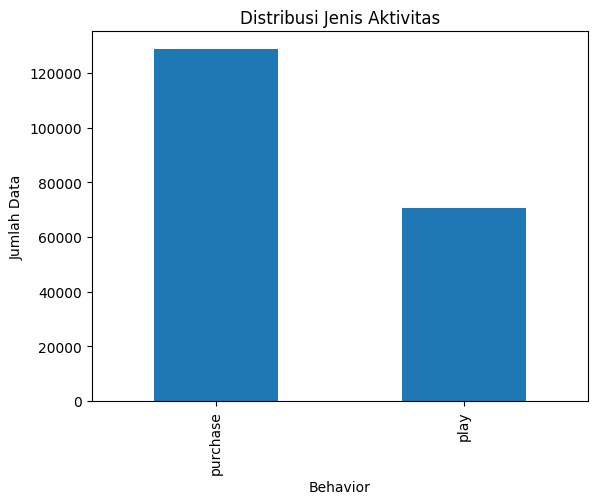

In [28]:
# Visualisasi distribusi jenis aktivitas
steam_data['behavior'].value_counts().plot(kind='bar')

plt.title('Distribusi Jenis Aktivitas')
plt.xlabel('Behavior')
plt.ylabel('Jumlah Data')
plt.show()

## **Mengambil Data Aktivitas Bermain**

Pada dataset ini terdapat dua jenis aktivitas, yaitu purchase dan play. Proyek ini menggunakan data play karena sistem rekomendasi dibuat berdasarkan lama waktu bermain pengguna.

Data purchase tidak digunakan karena hanya menunjukkan bahwa pengguna membeli game, tetapi belum tentu menunjukkan tingkat ketertarikan pengguna terhadap game tersebut.

**Insight:** Data play lebih relevan untuk sistem rekomendasi karena memiliki informasi hours yang dapat digunakan sebagai indikator preferensi pengguna.

In [29]:
# Mengambil data dengan aktivitas play
steam_play = steam_data[steam_data['behavior'] == 'play']

# Menampilkan 5 baris pertama data play
steam_play.head()

,user_id,game_title,behavior,hours
1,151603712,The Elder Scrolls V Skyrim,play,273.0
3,151603712,Fallout 4,play,87.0
5,151603712,Spore,play,14.9
7,151603712,Fallout New Vegas,play,12.1
9,151603712,Left 4 Dead 2,play,8.9


## **Melihat Ukuran Data Play**

Setelah data difilter hanya pada aktivitas play, ukuran dataset perlu dilihat kembali untuk mengetahui jumlah data yang akan digunakan pada proses berikutnya.

**Insight:** Jumlah data play menunjukkan banyaknya interaksi bermain yang dapat digunakan untuk membangun sistem rekomendasi.

In [30]:
# Melihat ukuran data setelah filter play
steam_play.shape

(70489, 4)

## **Statistik Deskriptif Data Play**

Setelah dataset difilter hanya pada aktivitas play, statistik deskriptif ditampilkan kembali untuk melihat gambaran lama waktu bermain pengguna.

Kolom hours menjadi fokus utama karena akan digunakan sebagai dasar pembuatan rating simulasi pada sistem rekomendasi.

**Insight:** Statistik deskriptif membantu melihat pola jam bermain pengguna, seperti nilai rata-rata, median, nilai minimum, dan nilai maksimum.

In [31]:
# Menampilkan statistik deskriptif pada data play
steam_play.describe()

,user_id,hours
count,7.048900e+04,70489.000000
mean,1.058812e+08,48.878063
std,7.150365e+07,229.335236
min,5.250000e+03,0.100000
25%,4.934256e+07,1.000000
50%,9.169067e+07,4.500000
75%,1.556738e+08,19.100000
max,3.099031e+08,11754.000000


## **Visualisasi Distribusi Jam Bermain**

Visualisasi distribusi jam bermain digunakan untuk melihat pola persebaran lama waktu bermain pengguna pada game Steam.

Pada visualisasi ini, data dibatasi sampai 100 jam agar pola distribusi lebih mudah dilihat. Data asli tidak dihapus, pembatasan hanya dilakukan untuk kebutuhan visualisasi.

**Insight:** Sebagian besar pengguna memiliki jam bermain yang relatif kecil, sedangkan beberapa pengguna memiliki jam bermain yang sangat tinggi.

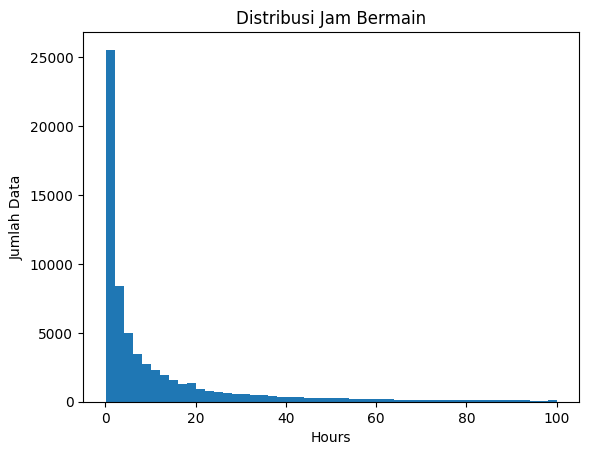

In [32]:
# Visualisasi distribusi jam bermain sampai 100 jam
steam_play[steam_play['hours'] <= 100]['hours'].plot(kind='hist', bins=50)

plt.title('Distribusi Jam Bermain')
plt.xlabel('Hours')
plt.ylabel('Jumlah Data')
plt.show()

## **Pengecekan Outlier Jam Bermain**

Pada tahap ini dilakukan pengecekan outlier pada kolom hours. Outlier perlu dilihat karena terdapat pengguna yang memiliki jam bermain sangat tinggi dibandingkan pengguna lainnya.

Berdasarkan hasil pengecekan, terdapat beberapa data dengan jam bermain sangat tinggi, seperti Sid Meier's Civilization V, Dota 2, dan Team Fortress 2.

**Insight:** Outlier pada kolom hours tetap dipertahankan karena jam bermain yang tinggi dapat menunjukkan minat pengguna yang kuat terhadap suatu game. Nilai ekstrem ini tidak langsung dihapus karena masih relevan untuk sistem rekomendasi.

In [35]:
# Melihat nilai hours terbesar
steam_play.sort_values(by='hours', ascending=False).head(10)

,user_id,game_title,behavior,hours
123726,73017395,Sid Meier's Civilization V,play,11754.0
112643,100630947,Dota 2,play,10442.0
187005,153382649,Team Fortress 2,play,9640.0
165596,130882834,Dota 2,play,7765.0
183461,52567955,Dota 2,play,6964.0
128440,121199670,Dota 2,play,6753.0
113436,86256882,Dota 2,play,6015.0
140270,70487610,Sid Meier's Civilization V,play,6013.0
96010,101414179,Dota 2,play,5982.0
141312,12660489,Dota 2,play,5970.0


## **Visualisasi Outlier Jam Bermain**

Boxplot digunakan untuk melihat keberadaan outlier pada kolom hours. Visualisasi ini menunjukkan bahwa terdapat beberapa nilai jam bermain yang jauh lebih tinggi dibandingkan data lainnya.

**Insight:** Outlier pada dataset ini wajar karena beberapa pengguna dapat memainkan game tertentu dalam waktu yang sangat lama. Data tersebut tetap digunakan karena dapat menjadi indikator preferensi pengguna.

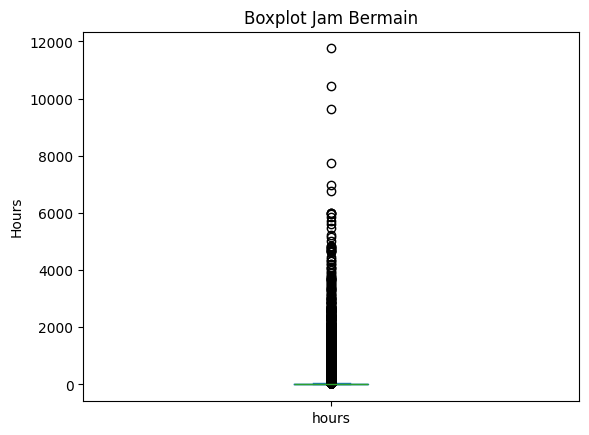

In [36]:
# Visualisasi outlier pada kolom hours
steam_play['hours'].plot(kind='box')

plt.title('Boxplot Jam Bermain')
plt.ylabel('Hours')
plt.show()

## **Game yang Paling Sering Dimainkan**

Pada tahap ini, ditampilkan 10 game yang paling sering muncul pada data play. Game yang sering muncul menunjukkan bahwa game tersebut banyak dimainkan oleh pengguna dalam dataset.

**Insight:** Informasi ini membantu memahami game apa saja yang paling banyak memiliki interaksi bermain dari pengguna.

In [33]:
# Melihat 10 game yang paling sering dimainkan
top_games = steam_play['game_title'].value_counts().head(10)

top_games

,count
game_title,
Dota 2,4841
Team Fortress 2,2323
Counter-Strike Global Offensive,1377
Unturned,1069
Left 4 Dead 2,801
Counter-Strike Source,715
The Elder Scrolls V Skyrim,677
Garry's Mod,666
Counter-Strike,568


## **Visualisasi Game yang Paling Sering Dimainkan**

Visualisasi ini digunakan untuk melihat 10 game dengan jumlah interaksi play terbanyak pada dataset.

**Insight:** Dota 2 menjadi game dengan jumlah interaksi play tertinggi, diikuti oleh Team Fortress 2 dan Counter-Strike Global Offensive. Hal ini menunjukkan bahwa beberapa game populer memiliki jumlah interaksi bermain yang jauh lebih besar dibanding game lainnya.

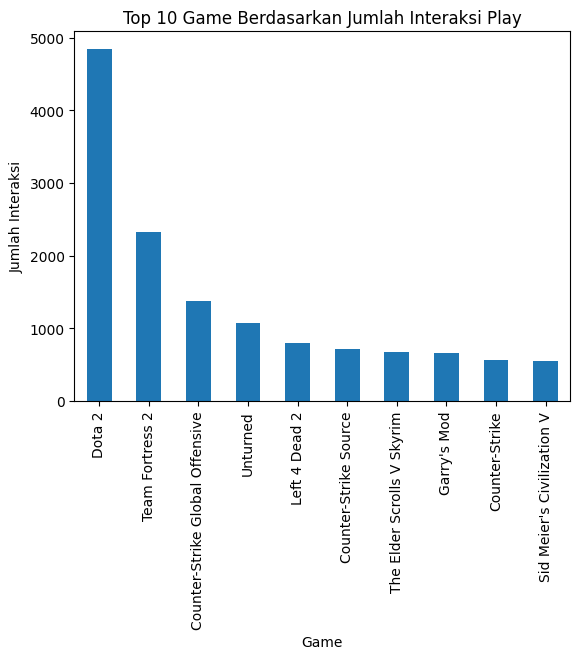

In [34]:
# Visualisasi 10 game yang paling sering dimainkan
top_games.plot(kind='bar')

plt.title('Top 10 Game Berdasarkan Jumlah Interaksi Play')
plt.xlabel('Game')
plt.ylabel('Jumlah Interaksi')
plt.xticks(rotation=90)
plt.show()

## **Menghitung Rata-Rata Jam Bermain Tiap Game**

Pada tahap ini, rata-rata jam bermain dihitung untuk setiap game. Nilai rata-rata ini digunakan sebagai pembanding dalam proses pembuatan rating simulasi.

**Insight:** Rata-rata jam bermain tiap game membantu mengukur apakah waktu bermain seorang pengguna berada di bawah atau di atas rata-rata pemain lain pada game yang sama.

In [37]:
# Menghitung rata-rata jam bermain tiap game
mean_hours = steam_play.groupby('game_title')['hours'].mean().reset_index()

# Mengubah nama kolom
mean_hours.columns = ['game_title', 'mean_hours']

# Menampilkan 5 baris pertama
mean_hours.head()

,game_title,mean_hours
0,007 Legends,0.70
1,0RBITALIS,0.40
2,1... 2... 3... KICK IT! (Drop That Beat Like a...,4.00
3,10 Second Ninja,2.95
4,"10,000,000",3.60


## **Menggabungkan Rata-Rata Jam Bermain**

Rata-rata jam bermain tiap game digabungkan kembali ke dataset play. Penggabungan ini dilakukan agar setiap baris data memiliki informasi jam bermain pengguna dan rata-rata jam bermain pada game yang sama.

**Insight:** Data hasil penggabungan digunakan untuk membuat rating simulasi berdasarkan perbandingan antara hours dan mean_hours.

In [38]:
# Menggabungkan rata-rata jam bermain ke data play
steam_play = steam_play.merge(mean_hours, on='game_title')

# Menampilkan 5 baris pertama
steam_play.head()

,user_id,game_title,behavior,hours,mean_hours
0,151603712,The Elder Scrolls V Skyrim,play,273.0,104.710931
1,151603712,Fallout 4,play,87.0,64.447904
2,151603712,Spore,play,14.9,29.424138
3,151603712,Fallout New Vegas,play,12.1,51.682578
4,151603712,Left 4 Dead 2,play,8.9,41.943446


## **Membuat Rating Simulasi**

Dataset Steam tidak memiliki rating eksplisit dari pengguna. Oleh karena itu, rating simulasi dibuat berdasarkan perbandingan antara jam bermain pengguna dan rata-rata jam bermain pada game yang sama.

Rating dihitung dari nilai hours dibagi mean_hours, lalu dikalikan 5.

**Insight:** Rating simulasi digunakan agar data dapat diproses oleh model collaborative filtering yang membutuhkan nilai rating pengguna terhadap game.

In [39]:
# Membuat rating simulasi berdasarkan jam bermain
steam_play['rating'] = (steam_play['hours'] / steam_play['mean_hours']) * 5

# Menampilkan 5 baris pertama
steam_play.head()

,user_id,game_title,behavior,hours,mean_hours,rating
0,151603712,The Elder Scrolls V Skyrim,play,273.0,104.710931,13.035888
1,151603712,Fallout 4,play,87.0,64.447904,6.749638
2,151603712,Spore,play,14.9,29.424138,2.531935
3,151603712,Fallout New Vegas,play,12.1,51.682578,1.170607
4,151603712,Left 4 Dead 2,play,8.9,41.943446,1.060952


## **Membatasi Nilai Rating**

Nilai rating simulasi dibatasi maksimal 5 agar sesuai dengan skala rating yang digunakan pada sistem rekomendasi.

**Insight:** Pembatasan rating membantu mengurangi pengaruh nilai hours yang terlalu besar, sehingga rating tetap berada pada skala yang konsisten.

In [40]:
# Membatasi nilai rating maksimal 5
steam_play['rating'] = steam_play['rating'].clip(upper=5)

# Menampilkan 5 baris pertama
steam_play.head()

,user_id,game_title,behavior,hours,mean_hours,rating
0,151603712,The Elder Scrolls V Skyrim,play,273.0,104.710931,5.000000
1,151603712,Fallout 4,play,87.0,64.447904,5.000000
2,151603712,Spore,play,14.9,29.424138,2.531935
3,151603712,Fallout New Vegas,play,12.1,51.682578,1.170607
4,151603712,Left 4 Dead 2,play,8.9,41.943446,1.060952


## **Visualisasi Distribusi Rating Simulasi**

Setelah rating simulasi dibuat, distribusi rating ditampilkan untuk melihat persebaran nilai rating yang digunakan pada model.

**Insight:** Visualisasi ini membantu memastikan bahwa rating simulasi sudah berada pada skala yang sesuai, yaitu maksimal 5.

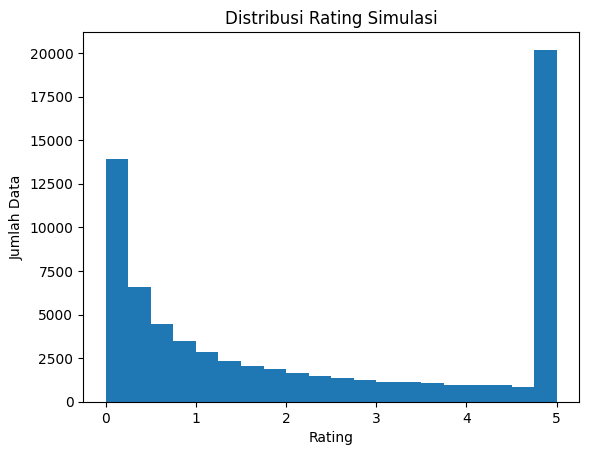

In [41]:
# Visualisasi distribusi rating simulasi
steam_play['rating'].plot(kind='hist', bins=20)

plt.title('Distribusi Rating Simulasi')
plt.xlabel('Rating')
plt.ylabel('Jumlah Data')
plt.show()

## **Menyiapkan Data untuk Model**

Pada tahap ini, data disiapkan dalam format yang dibutuhkan oleh model collaborative filtering. Kolom yang digunakan adalah user_id, game_title, dan rating.

**Insight:** Ketiga kolom ini digunakan karena sistem rekomendasi membutuhkan informasi pengguna, item, dan nilai preferensi pengguna terhadap item tersebut.

In [42]:
# Menyiapkan data untuk model
model_data = steam_play[['user_id', 'game_title', 'rating']]

# Menampilkan 5 baris pertama
model_data.head()

,user_id,game_title,rating
0,151603712,The Elder Scrolls V Skyrim,5.000000
1,151603712,Fallout 4,5.000000
2,151603712,Spore,2.531935
3,151603712,Fallout New Vegas,1.170607
4,151603712,Left 4 Dead 2,1.060952


## **Membuat Dataset Surprise**

Library Surprise digunakan untuk membangun model collaborative filtering. Data diubah ke format Surprise agar dapat digunakan pada algoritma K-NN dan SVD.

**Insight:** Format data Surprise membutuhkan user, item, dan rating agar model dapat mempelajari pola interaksi pengguna dengan game.

In [43]:
!pip install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 9.5 MB/s eta 0:00:00


In [44]:
from surprise import Dataset, Reader
from surprise import KNNBasic, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

In [45]:
# Membuat skala rating
reader = Reader(rating_scale=(0, 5))

# Mengubah dataframe ke format Surprise
data = Dataset.load_from_df(model_data, reader)

## **Membagi Data Training dan Testing**

Data dibagi menjadi data training dan data testing. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk mengevaluasi performa model.

**Insight:** Pembagian data membantu mengetahui kemampuan model dalam memprediksi data yang belum pernah dilihat sebelumnya.

In [46]:
# Membagi data menjadi training dan testing
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

## **Model K-NN**

Model pertama yang digunakan adalah K-NN dengan cosine similarity. Model ini bekerja dengan mencari kemiripan pola antar pengguna berdasarkan rating simulasi yang terbentuk dari jam bermain.

Setelah model dilatih, model digunakan untuk memprediksi rating pada data testing. Hasil prediksi kemudian dievaluasi menggunakan RMSE dan MAE.

**Insight:** K-NN digunakan sebagai model pembanding untuk melihat performa pendekatan berbasis kemiripan pengguna.

In [52]:
# Membuat model K-NN dengan metrik cosine
sim_options = {
    'name': 'cosine',
    'user_based': True
}

model_knn = KNNBasic(sim_options=sim_options)

# Melatih model K-NN dengan data pelatihan
model_knn.fit(trainset)

# Melakukan prediksi pada data pengujian
predictions_knn = model_knn.test(testset)

# Menghitung nilai RMSE dan MAE
rmse_knn = accuracy.rmse(predictions_knn)
mae_knn = accuracy.mae(predictions_knn)

Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 2.0402
MAE:  1.8189


## **Model SVD**

Model kedua yang digunakan adalah SVD. Model ini bekerja dengan mempelajari pola laten antara pengguna dan game pada data rating simulasi.

Setelah model dilatih, model digunakan untuk memprediksi rating pada data testing. Hasil prediksi kemudian dievaluasi menggunakan RMSE dan MAE.

**Insight:** SVD cocok digunakan pada sistem rekomendasi karena dapat menangani data interaksi pengguna dan item yang cenderung sparse.

In [53]:
# Membuat model SVD
model_svd = SVD(random_state=42)

# Melatih model SVD dengan data pelatihan
model_svd.fit(trainset)

# Melakukan prediksi pada data pengujian
predictions_svd = model_svd.test(testset)

# Menghitung nilai RMSE dan MAE
rmse_svd = accuracy.rmse(predictions_svd)
mae_svd = accuracy.mae(predictions_svd)

RMSE: 1.9321
MAE:  1.6680


## **Perbandingan Evaluasi Model**

Evaluasi dilakukan menggunakan RMSE dan MAE. RMSE mengukur rata-rata kesalahan prediksi dengan memberi penalti lebih besar pada kesalahan yang tinggi. MAE mengukur rata-rata selisih absolut antara rating asli dan rating prediksi.

Semakin kecil nilai RMSE dan MAE, maka performa model semakin baik.

**Insight:** Model dengan nilai RMSE dan MAE lebih kecil dipilih sebagai model utama karena memiliki kesalahan prediksi yang lebih rendah.

In [54]:
# Membuat tabel perbandingan evaluasi model
evaluation_result = pd.DataFrame({
    'Model': ['K-NN', 'SVD'],
    'RMSE': [rmse_knn, rmse_svd],
    'MAE': [mae_knn, mae_svd]
})

evaluation_result

,Model,RMSE,MAE
0,K-NN,2.040162,1.818874
1,SVD,1.932106,1.667971


## **Visualisasi Perbandingan Model**

Visualisasi ini digunakan untuk melihat perbandingan nilai RMSE dan MAE antara model K-NN dan SVD.

**Insight:** Model dengan nilai RMSE dan MAE lebih rendah memiliki performa prediksi rating yang lebih baik.

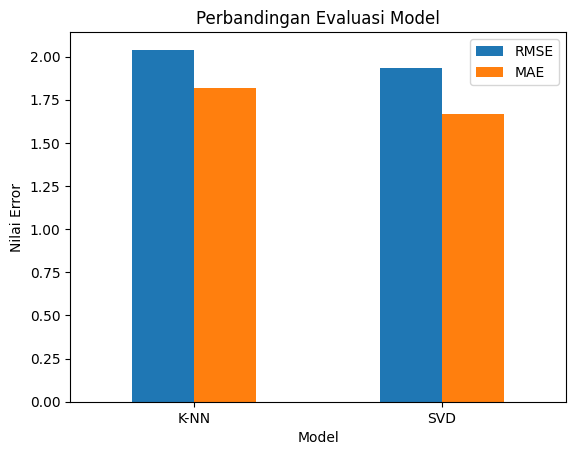

In [55]:
# Visualisasi perbandingan RMSE dan MAE
evaluation_result.set_index('Model').plot(kind='bar')

plt.title('Perbandingan Evaluasi Model')
plt.xlabel('Model')
plt.ylabel('Nilai Error')
plt.xticks(rotation=0)
plt.show()

## **Menyimpan Model dan Dataset**

Model terbaik disimpan dalam format pkl agar dapat digunakan kembali pada tahap deployment. Dataset yang sudah dibersihkan juga disimpan agar dapat digunakan oleh aplikasi rekomendasi.

**Insight:** Penyimpanan model dan dataset membantu proses deployment karena aplikasi dapat langsung memuat file yang sudah siap digunakan.

In [51]:
import pickle

# Menyimpan model SVD
with open('steam_svd_model.pkl', 'wb') as file:
    pickle.dump(model_svd, file)

# Menyimpan model K-NN sebagai pembanding
with open('steam_knn_model.pkl', 'wb') as file:
    pickle.dump(model_knn, file)

# Menyimpan dataset yang sudah dibersihkan
steam_play.to_csv('steam_cleaned.csv', index=False)

## **Kesimpulan**

Berdasarkan hasil proyek yang telah dilakukan, sistem rekomendasi game Steam dapat dibangun menggunakan pendekatan collaborative filtering. Dataset Steam tidak memiliki rating eksplisit dari pengguna, sehingga rating simulasi dibuat berdasarkan lama waktu bermain pengguna terhadap suatu game.

Pada tahap data preparation, data difilter hanya pada aktivitas play karena data tersebut lebih relevan untuk menunjukkan preferensi pengguna. Nilai hours dibandingkan dengan rata-rata jam bermain pada game yang sama, lalu dikonversi menjadi rating simulasi dengan skala maksimal 5.

Model yang digunakan adalah K-NN dan SVD. Kedua model dievaluasi menggunakan RMSE dan MAE. RMSE digunakan untuk mengukur rata-rata kesalahan prediksi dengan penalti lebih besar pada error yang tinggi, sedangkan MAE digunakan untuk mengukur rata-rata selisih absolut antara rating aktual dan rating prediksi.

Berdasarkan hasil evaluasi, model SVD memiliki nilai RMSE dan MAE yang lebih kecil dibandingkan model K-NN. Oleh karena itu, model SVD dipilih sebagai model utama karena memiliki kesalahan prediksi yang lebih rendah.

**Insight:** Proyek ini menunjukkan bahwa data jam bermain dapat digunakan sebagai dasar untuk membangun sistem rekomendasi game. Model SVD menjadi pilihan terbaik karena mampu memberikan performa prediksi yang lebih baik dibandingkan K-NN berdasarkan nilai RMSE dan MAE.